### Processing EMTP-RV outputs

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from simulation import ParamSimulation, Simulation

In [10]:
m_file = 'IEEE39_Wind_v5m.m'
mda_file = 'IEEE39_Wind_v5.mda'

# List of variable names:
prefix = 'PowerPlant_0'
teta = '/Teta_1_SM1'
omega = '/Omega_1_SM1'
# Choose sufix for variable names:
sufix = teta  # EDIT HERE

white_list = [prefix + f'{i+1}' + sufix for i in range(9) if i != 7]
white_list

['PowerPlant_01/Teta_1_SM1',
 'PowerPlant_02/Teta_1_SM1',
 'PowerPlant_03/Teta_1_SM1',
 'PowerPlant_04/Teta_1_SM1',
 'PowerPlant_05/Teta_1_SM1',
 'PowerPlant_06/Teta_1_SM1',
 'PowerPlant_07/Teta_1_SM1',
 'PowerPlant_09/Teta_1_SM1']

In [11]:
# Read .m file:
ps = ParamSimulation(m_file, white_list)

In [12]:
# Read simulation .mda file.
sim = Simulation(mda_file, m_file, white_list)
sim.load_data()

In [13]:
# Simulation time (x-axis) for plotting.
time = sim._ft

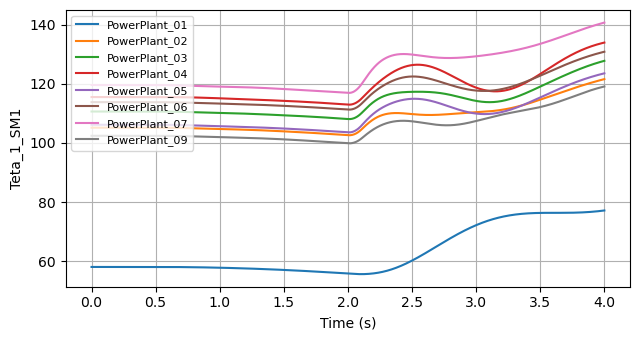

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
for i in range(len(white_list)):
    ax.plot(time, sim._data[i],  # plot signals
            ls='-', lw=1.5, label=white_list[i][:13])
ax.legend(loc='upper left', frameon=True, fancybox=True, fontsize=8)
ax.grid(which='major', axis='both')
ax.set_xlabel('Time (s)')
ax.set_ylabel(sufix[1:])
fig.tight_layout()
plt.show()